# 1.6. Визуализация и графика

### Beam.draw()

`draw(pictorial=True)`

Возвращает объект графика, представляющий расчетную схему балки. В частности, схема может включать:

- балку;
- вертикальные черные стрелки, обозначающие сосредоточенные силы и опорные реакции (последние, если они были добавлены с помощью метода `apply_load`);
- круговые стрелки, обозначающие моменты;
- заштрихованные области, обозначающие распределенные нагрузки;
- опору, если был выполнен метод `apply_support`;
- если с помощью метода `join` была создана составная балка и задан шарнир, он будет показан в виде белого кружка.

На схеме положительные нагрузки отображаются с верхней стороны балки, а отрицательные — с нижней. Если две или более распределенные нагрузки действуют в одном направлении на одном и том же участке, функция суммирует их вместе.

> [!note]
> Пользователь должен быть внимателен при вводе значений нагрузок. Функция `draw` предполагает правило знаков, используемое для отрисовки нагрузок. При использовании правой системы координат XYZ, длина балки располагается вдоль положительной оси X. Функция `draw` распознает положительные нагрузки (с n>-2) как нагрузки, действующие в отрицательном направлении оси Y, и положительные моменты, действующие в положительном направлении оси Z.

**Параметры**

**pictorial: Булево значение (по умолчанию True)**

> Установка `pictorial=True` создает просто схематичное (масштабированное) изображение схемы балки. С другой стороны, `pictorial=False` создает схему балки с точными размерами на графике.

In [24]:
from sympy.physics.continuum_mechanics.beam import Beam
from sympy import symbols
P1, P2, M = symbols('P1, P2, M')
E, I = symbols('E, I')
b = Beam(50, 20, 30)
b.apply_load(-10, 2, -1)
b.apply_load(15, 26, -1)
b.apply_load(P1, 10, -1)
b.apply_load(-P2, 40, -1)
b.apply_load(90, 5, 0, 23)
b.apply_load(10, 30, 1, 50)
b.apply_load(M, 15, -2)
b.apply_load(-M, 30, -2)
p50 = b.apply_support(50, "pin")
p0, m0 = b.apply_support(0, "fixed")
p20 = b.apply_support(20, "roller")

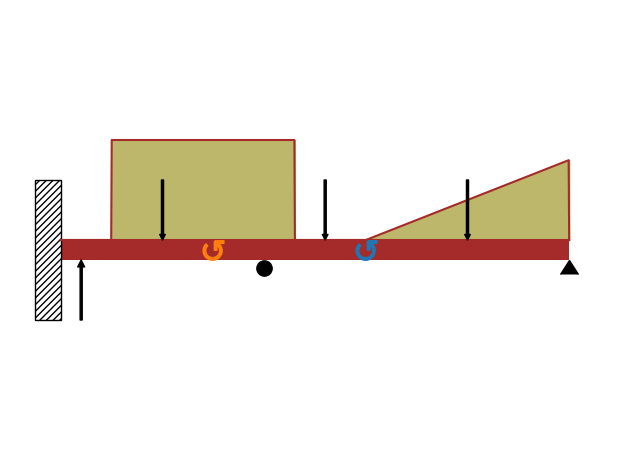

In [26]:
p = b.draw()
p.show()

### Beam.plot_shear_force()

`plot_shear_force(subs=None)`

Возвращает график поперечной силы для объекта «Балка».

**Параметры**

**pubs**: словарь

> Словарь Python, содержащий символы в качестве ключей и их соответствующие значения.

#### Пример

Имеется балка длиной 8 метров. Постоянная распределённая нагрузка 10 кН/м приложена от середины балки до её конца. Под балкой расположены две простые опоры: одна в начале и одна в конце балки. Сосредоточенная сила величиной 5 кН также приложена сверху балки на расстоянии 4 метра от начала. Принять E = 200 ГПа и I = 400*(10**-6) м**4.

Используется правило знаков: силы, направленные вниз, положительны.

In [27]:
from sympy.physics.continuum_mechanics.beam import Beam
from sympy import symbols
R1, R2 = symbols('R1, R2')
b = Beam(8, 200*(10**9), 400*(10**-6))
b.apply_load(5000, 2, -1)
b.apply_load(R1, 0, -1)
b.apply_load(R2, 8, -1)
b.apply_load(10000, 4, 0, end=8)
b.bc_deflection = [(0, 0), (8, 0)]
b.solve_for_reaction_loads(R1, R2)

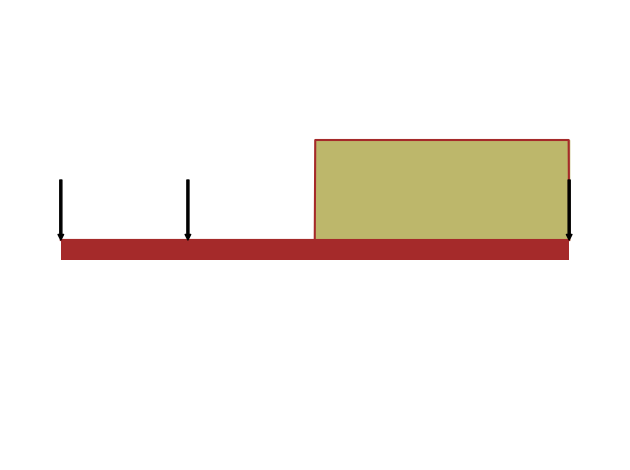

In [28]:
p = b.draw()
p.show()

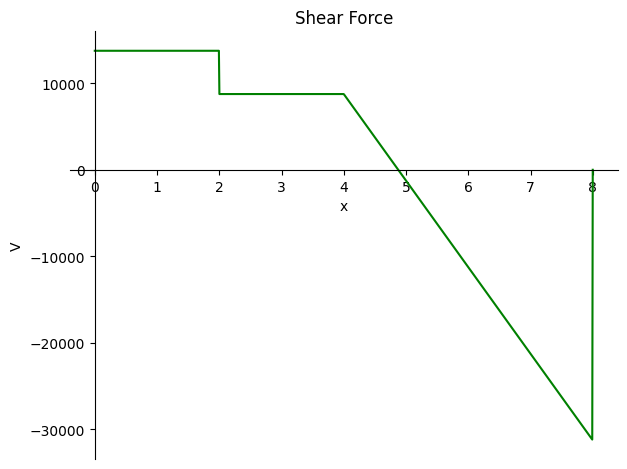

In [3]:
b.plot_shear_force();

### Beam.plot_shear_stress()

`plot_shear_stress(subs=None)`

Возвращает график касательных напряжений, возникающих в объекте «Балка».

**Параметры**

**pubs**: словарь

> Словарь Python, содержащий символы в качестве ключей и их соответствующие значения.

#### Пример

Имеется балка длиной 8 метров и площадью поперечного сечения 2 квадратных метра. Постоянная распределённая нагрузка 10 кН/м приложена от середины балки до её конца. Под балкой расположены две простые опоры: одна в начале и одна в конце балки. Сосредоточенная сила величиной 5 кН также приложена сверху балки на расстоянии 4 метра от начала. Принять E = 200 ГПа и I = 400*(10**-6) м**4.

Используется правило знаков: силы, направленные вниз, положительны.

In [4]:
from sympy.physics.continuum_mechanics.beam import Beam
from sympy import symbols
R1, R2 = symbols('R1, R2')
b = Beam(8, 200*(10**9), 400*(10**-6), 2)
b.apply_load(5000, 2, -1)
b.apply_load(R1, 0, -1)
b.apply_load(R2, 8, -1)
b.apply_load(10000, 4, 0, end=8)
b.bc_deflection = [(0, 0), (8, 0)]
b.solve_for_reaction_loads(R1, R2)

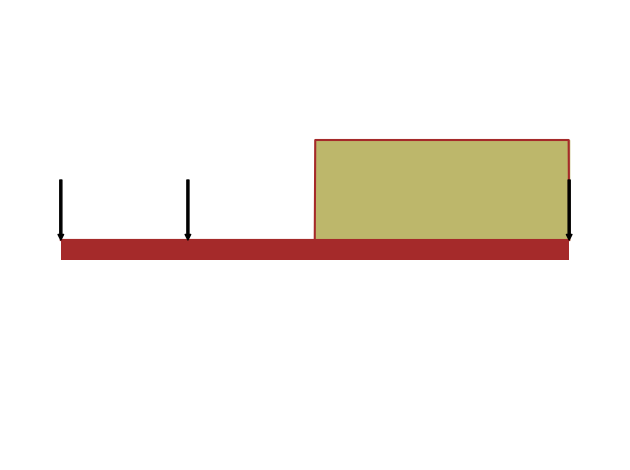

In [5]:
p = b.draw()
p.show()

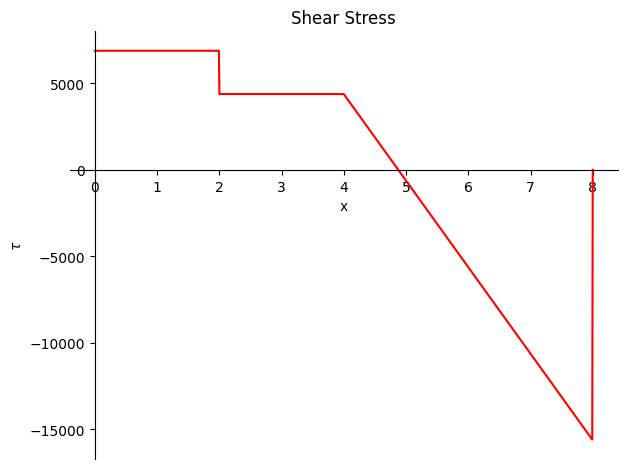

In [6]:
b.plot_shear_stress();

### Beam.plot_bending_moment()

`plot_bending_moment(subs=None)`

Возвращает график изгибающего момента для объекта «Балка».

**Параметры**

**subs**: словарь

> Словарь Python, содержащий символы в качестве ключей и их соответствующие значения.

#### Пример

Имеется балка длиной 8 метров. Постоянная распределённая нагрузка 10 кН/м приложена от середины балки до её конца. Под балкой расположены две простые опоры: одна в начале и одна в конце балки. Сосредоточенная сила величиной 5 кН также приложена сверху балки на расстоянии 4 метра от начала. Принять E = 200 ГПа и I = 400*(10**-6) м**4.

Используется правило знаков: силы, направленные вниз, положительны.

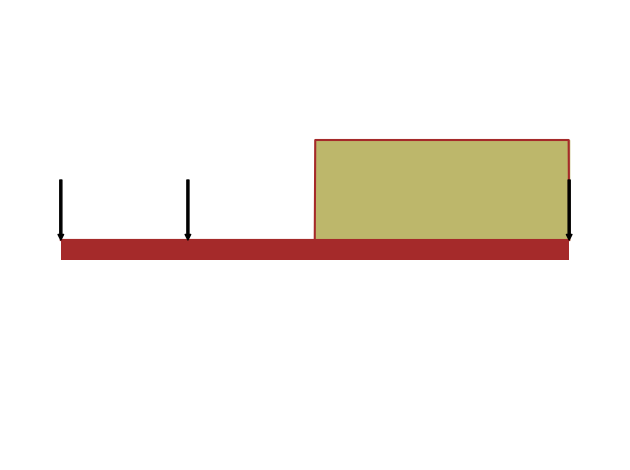

In [7]:
from sympy.physics.continuum_mechanics.beam import Beam
from sympy import symbols
R1, R2 = symbols('R1, R2')
b = Beam(8, 200*(10**9), 400*(10**-6))
b.apply_load(5000, 2, -1)
b.apply_load(R1, 0, -1)
b.apply_load(R2, 8, -1)
b.apply_load(10000, 4, 0, end=8)
b.bc_deflection = [(0, 0), (8, 0)]
b.solve_for_reaction_loads(R1, R2)
p = b.draw()
p.show()

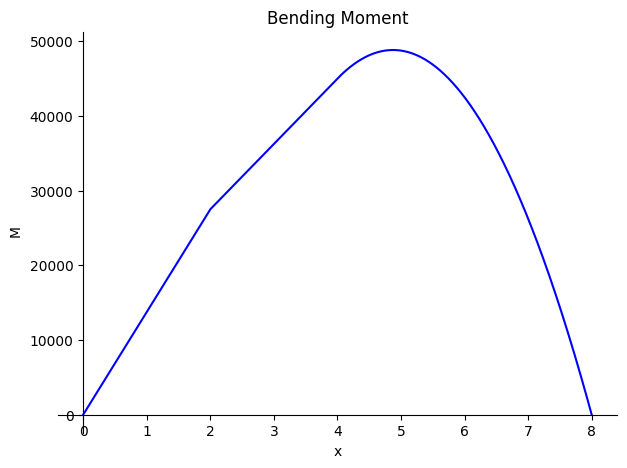

In [8]:
b.plot_bending_moment();

### Beam.plot_slope()

`plot_slope(subs=None)`

Возвращает график углов наклона кривой прогибов.

Параметры:

**pubs**: словарь

> Словарь Python, содержащий символы в качестве ключей и их соответствующие значения.

#### Пример

Имеется балка длиной 8 метров. Постоянная распределённая нагрузка 10 кН/м приложена от середины балки до её конца. Под балкой расположены две простые опоры: одна в начале и одна в конце балки. Сосредоточенная сила величиной 5 кН также приложена сверху балки на расстоянии 4 метра от начала. Принять E = 200 ГПа и I = 400*(10**-6) м**4.

Используется правило знаков: силы, направленные вниз, положительны.

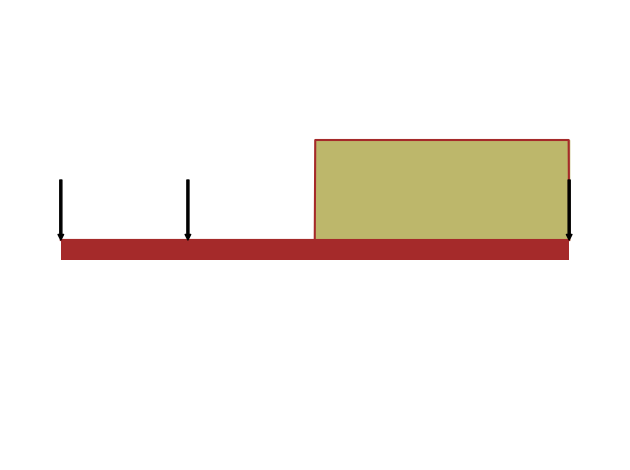

In [9]:
from sympy.physics.continuum_mechanics.beam import Beam
from sympy import symbols
R1, R2 = symbols('R1, R2')
b = Beam(8, 200*(10**9), 400*(10**-6))
b.apply_load(5000, 2, -1)
b.apply_load(R1, 0, -1)
b.apply_load(R2, 8, -1)
b.apply_load(10000, 4, 0, end=8)
b.bc_deflection = [(0, 0), (8, 0)]
b.solve_for_reaction_loads(R1, R2)
p = b.draw()
p.show()

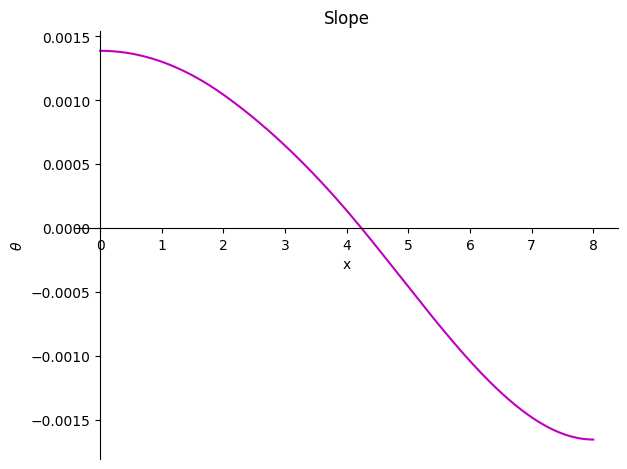

In [10]:
b.plot_slope();

### Beam.plot_deflection()

`plot_deflection(subs=None)`

Возвращает график кривой прогибов для объекта «Балка».

**Параметры**

**subs**: словарь

> Словарь Python, содержащий символы в качестве ключей и их соответствующие значения.

#### Пример

Имеется балка длиной 8 метров. Постоянная распределённая нагрузка 10 кН/м приложена от середины балки до её конца. Под балкой расположены две простые опоры: одна в начале и одна в конце балки. Сосредоточенная сила величиной 5 кН также приложена сверху балки на расстоянии 4 метра от начала. Принять E = 200 ГПа и I = 400*(10**-6) м**4.

Используется правило знаков: силы, направленные вниз, положительны.

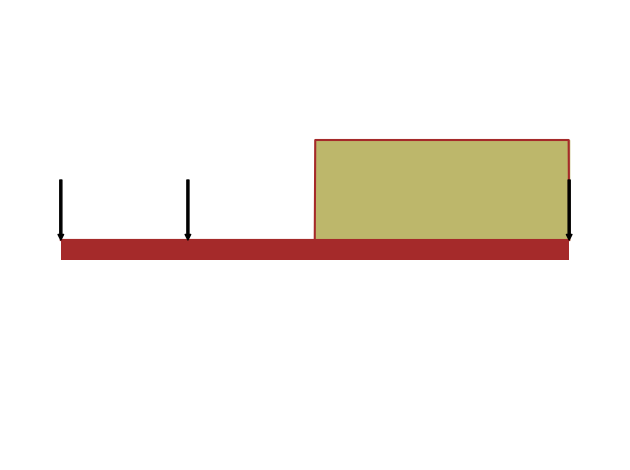

In [11]:
from sympy.physics.continuum_mechanics.beam import Beam
from sympy import symbols
R1, R2 = symbols('R1, R2')
b = Beam(8, 200*(10**9), 400*(10**-6))
b.apply_load(5000, 2, -1)
b.apply_load(R1, 0, -1)
b.apply_load(R2, 8, -1)
b.apply_load(10000, 4, 0, end=8)
b.bc_deflection = [(0, 0), (8, 0)]
b.solve_for_reaction_loads(R1, R2)
p = b.draw()
p.show()

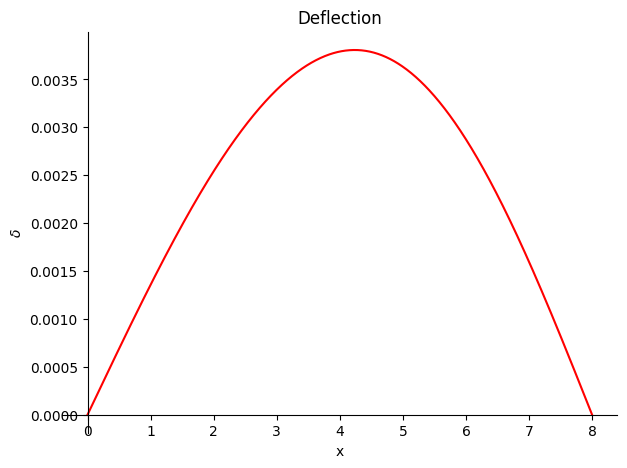

In [12]:
b.plot_deflection();

### Beam.plot_loading_results()
Возвращает субплоты для поперечной силы, изгибающего момента, наклона и прогиба объекта балки в заданном направлении.

**Параметры:**

**dir:** строка (по умолчанию='x')

> Направление, для которого требуется построить графики. Если направление не указано, отображаются графики вдоль оси x.

**subs:** словарь

> Python-словарь, содержащий символы в качестве ключей и соответствующие значения.

#### Пример

Есть балка длиной 20 метров. Оба конца поддерживаются роликами. Линейная нагрузка с наклоном 12 приложена вдоль оси y. Постоянная распределенная нагрузка величиной 15 Н приложена вдоль оси z от начала до конца.

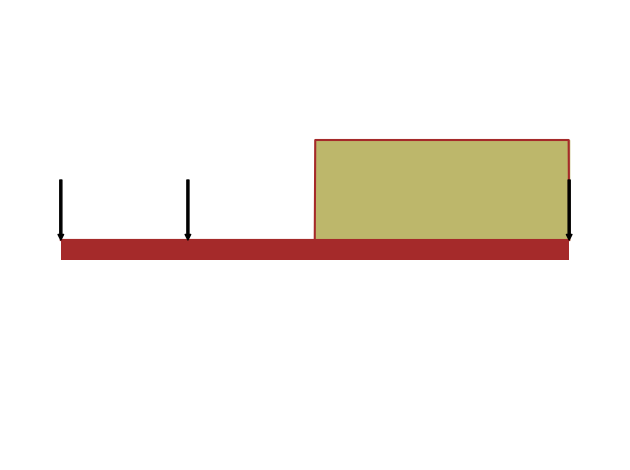

In [13]:
from sympy.physics.continuum_mechanics.beam import Beam
from sympy import symbols
R1, R2 = symbols('R1, R2')
b = Beam(8, 200*(10**9), 400*(10**-6))
b.apply_load(5000, 2, -1)
b.apply_load(R1, 0, -1)
b.apply_load(R2, 8, -1)
b.apply_load(10000, 4, 0, end=8)
b.bc_deflection = [(0, 0), (8, 0)]
b.solve_for_reaction_loads(R1, R2)
p = b.draw()
p.show()

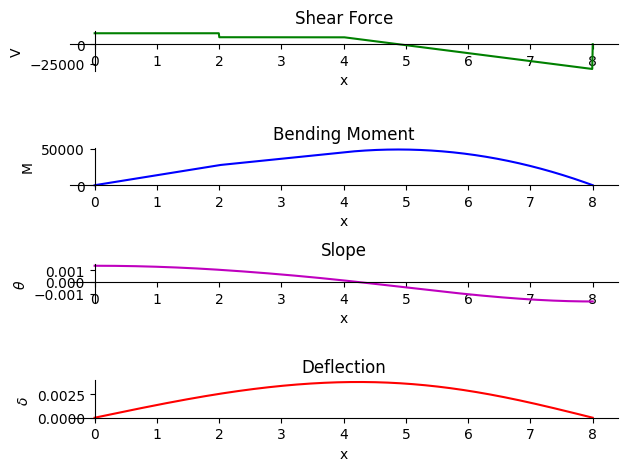

In [14]:
axes = b.plot_loading_results()

### Beam.plot_ild_moment()

`plot_ild_moment(subs=None)`

Строит линию влияния для момента при воздействии подвижной нагрузки. Эту функцию следует вызывать после выполнения solve_for_ild_moment().

**Параметры**

**subs**: словарь

> Словарь Python, содержащий символы в качестве ключей и их соответствующие значения.

> [!note]
> Значения при a = 0 и a = l, где l — длина балки, на графике могут быть некорректными.

#### Пример

Имеется балка длиной 12 метров. Под балкой расположены две простые опоры: одна в начале и одна на расстоянии 8 метров. Построить линию влияния для момента на расстоянии 4 метров от начала при воздействии подвижной нагрузки величиной 1 кН.

Используется правило знаков: силы, направленные вниз, положительны.

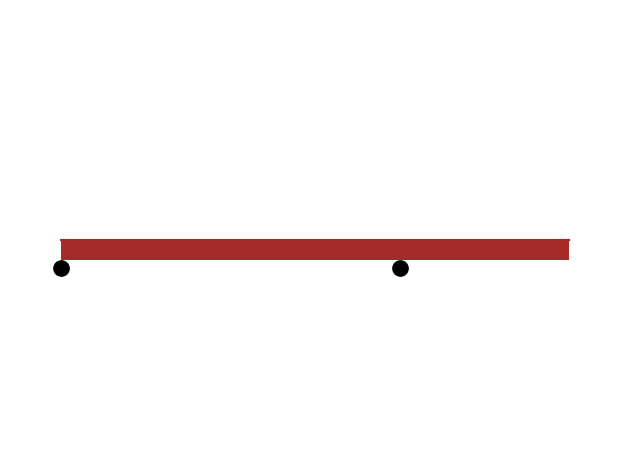

In [15]:
from sympy import symbols
from sympy.physics.continuum_mechanics.beam import Beam
E, I = symbols('E, I')
R_0, R_8 = symbols('R_0, R_8')
b = Beam(12, E, I)
p0 = b.apply_support(0, 'roller')
p8 = b.apply_support(8, 'roller')
b.solve_for_ild_reactions(1, R_0, R_8)
b.solve_for_ild_moment(4, 1, R_0, R_8)
p = b.draw()
p.show()

In [16]:
b.ild_moment

-(4*SingularityFunction(a, 0, 0) - SingularityFunction(a, 0, 1) + SingularityFunction(a, 4, 1))*SingularityFunction(a, 4, 0) - SingularityFunction(a, 0, 1)/2 + SingularityFunction(a, 4, 1) - 2*SingularityFunction(a, 12, 0) - SingularityFunction(a, 12, 1)/2

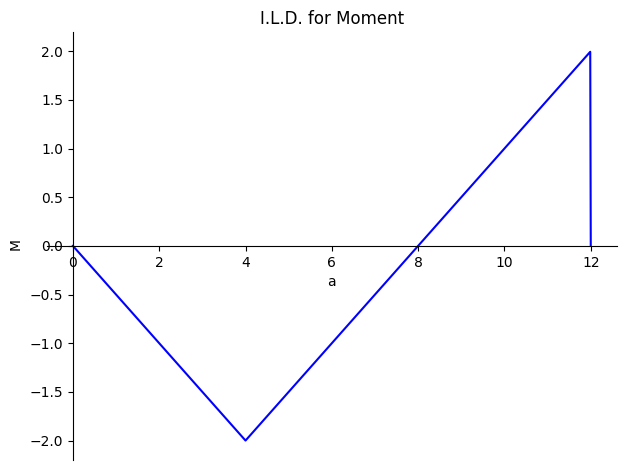

In [17]:
b.plot_ild_moment();

### Beam.plot_ild_reactions()

`plot_ild_reactions(subs=None)`

Строит линию влияния для опорных реакций при воздействии подвижной нагрузки. Эту функцию следует вызывать после выполнения solve_for_ild_reactions().

**Параметры**

**subs**: словарь

> Словарь Python, содержащий символы в качестве ключей и их соответствующие значения.

> [!note]
> Значения при a = 0 и a = l, где l — длина балки, на графике могут быть некорректными.

#### Пример

Имеется балка длиной 10 метров. Сосредоточенная сила величиной 5 кН также приложена сверху балки на расстоянии 4 метра от начала. Под балкой расположены две простые опоры: в начале и на расстоянии 7 метров от начала. Построить уравнения линий влияния для реакций в обеих опорных точках при воздействии подвижной нагрузки величиной 1 кН.

Используется правило знаков: силы, направленные вниз, положительны.

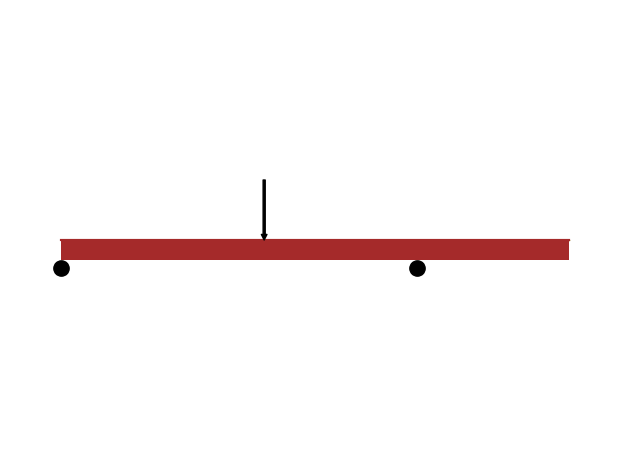

In [18]:
from sympy import symbols
from sympy.physics.continuum_mechanics.beam import Beam
E, I = symbols('E, I')
R_0, R_7 = symbols('R_0, R_7')
b = Beam(10, E, I)
p0 = b.apply_support(0, 'roller')
p7 = b.apply_support(7, 'roller')
b.apply_load(5,4,-1)
b.solve_for_ild_reactions(1,R_0,R_7)
p = b.draw()
p.show()

In [19]:
b.ild_reactions

{R_0: -SingularityFunction(a, 0, 0) + SingularityFunction(a, 0, 1)/7 - 3*SingularityFunction(a, 10, 0)/7 - SingularityFunction(a, 10, 1)/7 - 15/7,
 R_7: -SingularityFunction(a, 0, 1)/7 + 10*SingularityFunction(a, 10, 0)/7 + SingularityFunction(a, 10, 1)/7 - 20/7}

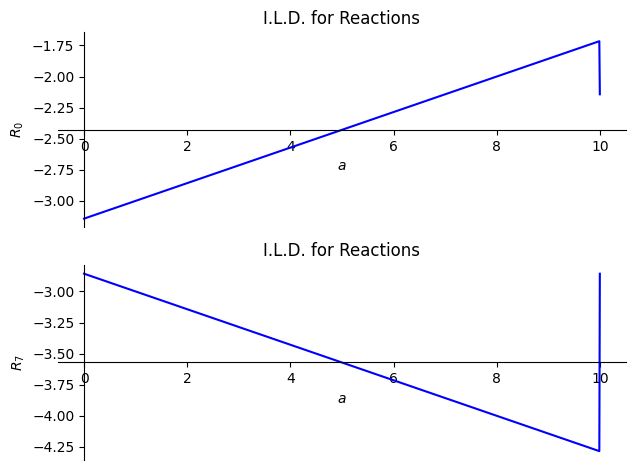

In [20]:
b.plot_ild_reactions();

### Beam.plot_ild_shear()

`plot_ild_shear(subs=None)`

Строит линию влияния для поперечной силы при воздействии подвижной нагрузки. Эту функцию следует вызывать после выполнения solve_for_ild_shear().

**Параметры**

**pubs**: словарь

> Словарь Python, содержащий символы в качестве ключей и их соответствующие значения.

> [!note]
> Значения при a = 0 и a = l, где l — длина балки, на графике могут быть некорректными.

#### Пример

Имеется балка длиной 12 метров. Под балкой расположены две простые опоры: одна в начале и одна на расстоянии 8 метров. Построить линию влияния для поперечной силы на расстоянии 4 метров от начала при воздействии подвижной нагрузки величиной 1 кН.

Используется правило знаков: силы, направленные вниз, положительны.

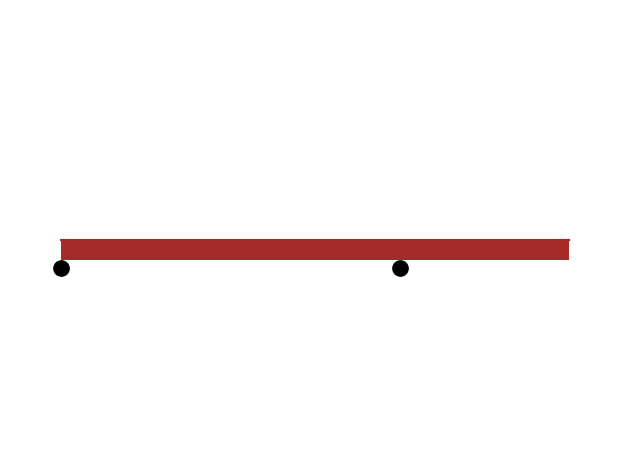

In [21]:
from sympy import symbols
from sympy.physics.continuum_mechanics.beam import Beam
E, I = symbols('E, I')
R_0, R_8 = symbols('R_0, R_8')
b = Beam(12, E, I)
p0 = b.apply_support(0, 'roller')
p8 = b.apply_support(8, 'roller')
b.solve_for_ild_reactions(1, R_0, R_8)
b.solve_for_ild_shear(4, 1, R_0, R_8)
p = b.draw()
p.show()


In [22]:
b.ild_shear

-(-SingularityFunction(a, 0, 0) + SingularityFunction(a, 12, 0) + 2)*SingularityFunction(a, 4, 0) - SingularityFunction(-a, 0, 0) - SingularityFunction(a, 0, 0) + SingularityFunction(a, 0, 1)/8 + SingularityFunction(a, 12, 0)/2 - SingularityFunction(a, 12, 1)/8 + 1

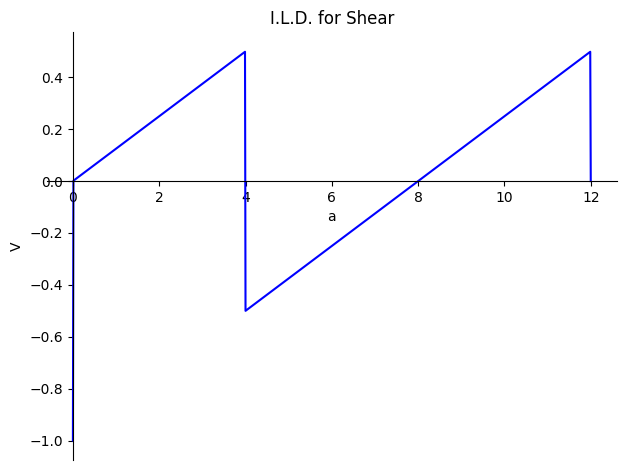

In [23]:
b.plot_ild_shear();